In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore') 

In [2]:
# Load dataset
df = pd.read_csv('flightfarepred.csv') 
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [3]:
df.head() 

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail() 

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.shape

(10683, 11)

In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe() 

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Data Cleaning

In [8]:
# Handling missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.dropna(inplace=True) 

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

## Feature Engineering

In [11]:
# Date conversion
df['Journey_day'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.day
df['Journey_month'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.month 
df.drop('Date_of_Journey', axis=1, inplace=True) 

In [12]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month'],
      dtype='object')

In [13]:
# Time features
df['Dep_hour'] = pd.to_datetime(df['Dep_Time']).dt.hour 
df['Dep_minute'] = pd.to_datetime(df['Dep_Time']).dt.minute 
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour 
df['Arrival_minute'] = pd.to_datetime(df['Arrival_Time']).dt.minute 

df.drop(['Dep_Time', 'Arrival_Time'], axis = 1, inplace=True) 

In [14]:
df.columns 

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_minute', 'Arrival_hour', 'Arrival_minute'],
      dtype='object')

In [15]:
# Duration conversion
def convert_duration(x):
   x = str(x) 
   hours = 0 
   minutes = 0 
   if 'h' in x:
       hours = int(x.split('h')[0]) 
   if 'm' in x: 
       minutes = int(x.split('h')[-1].replace('m','').strip()) 
   return hours*60 + minutes 
df['Duration'] = df['Duration'].apply(convert_duration)

In [16]:
df['Total_Stops'].unique() 

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [17]:
# Stops conversion
dict = {
    'non-stop':0, 
    '1 stop':1, 
    '2 stops':2, 
    '3 stops':3, 
    '4 stops':4
}
df['Total_Stops'] = df['Total_Stops'].replace(dict) 

In [18]:
df.head() 

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,0,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1,No info,13302,1,3,16,50,21,35


In [19]:
df['Route_points'] = df['Route'].apply(lambda x: len(str(x).split('→')))

In [20]:
df.Additional_Info.value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [21]:
df['Additional_Info'] = df['Additional_Info'].str.lower()
df['Extra_info'] = df['Additional_Info'].apply(lambda x: 0 if x== 'no info' else 1) 

In [22]:
df.drop(['Route', 'Additional_Info'], axis=1, inplace=True)

In [23]:
df.head() 

,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Route_points,Extra_info
0,IndiGo,Banglore,New Delhi,170,0,3897,24,3,22,20,1,10,2,0
1,Air India,Kolkata,Banglore,445,2,7662,1,5,5,50,13,15,4,0
2,Jet Airways,Delhi,Cochin,1140,2,13882,9,6,9,25,4,25,4,0
3,IndiGo,Kolkata,Banglore,325,1,6218,12,5,18,5,23,30,3,0
4,IndiGo,Banglore,New Delhi,285,1,13302,1,3,16,50,21,35,3,0


## Exploratory Data Analysis(EDA)

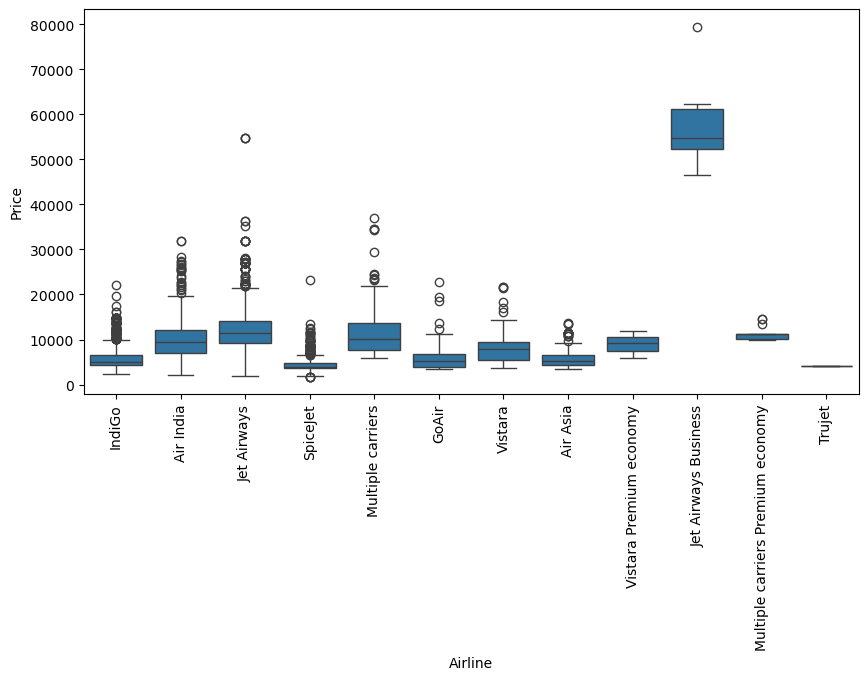

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Airline', y='Price', data=df) 
plt.xticks(rotation=90)
plt.show() 

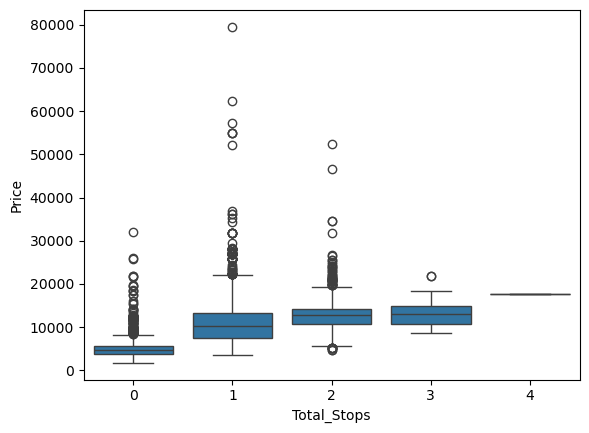

In [25]:
sns.boxplot(x='Total_Stops', y='Price', data=df) 
plt.show() 

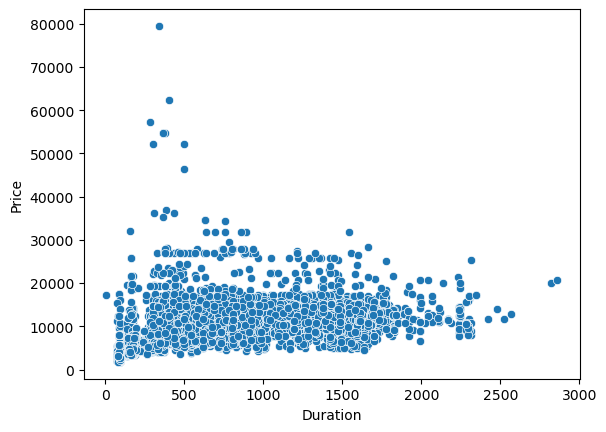

In [26]:
sns.scatterplot(x='Duration', y='Price', data=df) 
plt.show()

## Data Preprocessing

In [27]:
df = pd.get_dummies(df, drop_first=True) 

In [28]:
df.head()

,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Route_points,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,170,0,3897,24,3,22,20,1,10,2,...,False,False,False,False,False,False,False,False,False,True
1,445,2,7662,1,5,5,50,13,15,4,...,False,False,False,True,False,False,False,False,False,False
2,1140,2,13882,9,6,9,25,4,25,4,...,False,False,True,False,False,True,False,False,False,False
3,325,1,6218,12,5,18,5,23,30,3,...,False,False,False,True,False,False,False,False,False,False
4,285,1,13302,1,3,16,50,21,35,3,...,False,False,False,False,False,False,False,False,False,True


In [29]:
df = df.astype(int)

In [30]:
df.head()

,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Route_points,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,170,0,3897,24,3,22,20,1,10,2,...,0,0,0,0,0,0,0,0,0,1
1,445,2,7662,1,5,5,50,13,15,4,...,0,0,0,1,0,0,0,0,0,0
2,1140,2,13882,9,6,9,25,4,25,4,...,0,0,1,0,0,1,0,0,0,0
3,325,1,6218,12,5,18,5,23,30,3,...,0,0,0,1,0,0,0,0,0,0
4,285,1,13302,1,3,16,50,21,35,3,...,0,0,0,0,0,0,0,0,0,1


In [31]:
X = df.drop('Price', axis=1)
y = df['Price'] 

In [32]:
X

,Duration,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Route_points,Extra_info,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,170,0,24,3,22,20,1,10,2,0,...,0,0,0,0,0,0,0,0,0,1
1,445,2,1,5,5,50,13,15,4,0,...,0,0,0,1,0,0,0,0,0,0
2,1140,2,9,6,9,25,4,25,4,0,...,0,0,1,0,0,1,0,0,0,0
3,325,1,12,5,18,5,23,30,3,0,...,0,0,0,1,0,0,0,0,0,0
4,285,1,1,3,16,50,21,35,3,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,150,0,9,4,19,55,22,25,2,0,...,0,0,0,1,0,0,0,0,0,0
10679,155,0,27,4,20,45,23,20,2,0,...,0,0,0,1,0,0,0,0,0,0
10680,180,0,27,4,8,20,11,20,2,0,...,0,0,0,0,0,0,1,0,0,0
10681,160,0,1,3,11,30,14,10,2,0,...,0,0,0,0,0,0,0,0,0,1


In [33]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10682, dtype: int64

## Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

## Linear Regression 

In [36]:
from sklearn.linear_model import LinearRegression 

In [37]:
linear_model = LinearRegression() 
linear_model.fit(X_train, y_train) 

LinearRegression()

In [38]:
y_pred = linear_model.predict(X_test)

In [39]:
from sklearn.metrics import r2_score 

In [40]:
r2 = r2_score(y_test, y_pred) 
r2 

0.6679432861852912

In [41]:
from sklearn.metrics import mean_absolute_error 

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mae 

1849.9937628245768

In [43]:
from sklearn.metrics import mean_squared_error 

In [44]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
rmse 

np.float64(2675.7850373467636)

## Decision Tree Regressor

In [45]:
from sklearn.tree import DecisionTreeRegressor 

In [46]:
tree_model = DecisionTreeRegressor() 
tree_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [47]:
y_pred1 = tree_model.predict(X_test)

In [48]:
from sklearn.metrics import r2_score 

In [49]:
r2 = r2_score(y_test, y_pred1) 
r2 

0.8913311435656531

In [50]:
from sklearn.metrics import mean_absolute_error

In [51]:
mae1 = mean_absolute_error(y_test, y_pred1)
mae1

647.832787396662

In [52]:
from sklearn.metrics import mean_squared_error

In [53]:
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
rmse1

np.float64(1530.7266258609466)

## Random Forest Regressor 

In [54]:
from sklearn.ensemble import RandomForestRegressor 

In [55]:
random_model = RandomForestRegressor() 
random_model.fit(X_train, y_train) 

RandomForestRegressor()

In [56]:
y_pred2 = random_model.predict(X_test)

In [57]:
from sklearn.metrics import r2_score 

In [58]:
r2 = r2_score(y_test, y_pred2) 
r2 

0.899557830815302

In [59]:
from sklearn.metrics import mean_absolute_error 

In [60]:
mae2 = mean_absolute_error(y_test, y_pred2)
mae2 

633.2212605009248

In [61]:
from sklearn.metrics import mean_squared_error

In [62]:
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
rmse2 

np.float64(1471.6452389354731)

## Model Comparison

In [63]:
models = ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor']
scores = [0.6679432861852912, 0.8857899786470481, 0.8976703427662952]
mae_error = [1849.9937628245768, 657.7426298549368, 626.2723550075334] 
rmse_error = [2675.7850373467636, 1569.268273175772, 1469.5722928184514] 
comparison = pd.DataFrame({
    'Model': models,
    'R2 Score': scores, 
    'MAE': mae_error, 
    'RMSE': rmse_error
})
comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.667943,1849.993763,2675.785037
1,Decision Tree Regressor,0.885790,657.742630,1569.268273
2,Random Forest Regressor,0.897670,626.272355,1469.572293


## Model Comparison Report 

In this project multiple regression model were trained which are:
  - Linear Regression
  - Decision Tree Regressor
  - Random Forest Regressor
    
The performance of each models was evaluated using R2 Score, Mean Absolute Error and Root Mean Squared Error. The comparison of multiple models shows that Random Forest Regressor is the best with the highest R2 Score and lowest error values. Therefore, it is recommended as the best model for production use in predicting flight ticket prices.

## Challenges Faced Report

During the development of the flight price prediction model, several challenges were encountered: 
- Some records had missing data, which could affect model performance. So, missing values were removed using dropna() to ensure data quality.
- Columns like Date_of_Journey, Dep_Time and Arrival_Time were not in proper numerical format. So, useful features such as day, month, hour and minute were extracted.
- The duration columns was in text format for example 2h 30m, so it was converted into total minutes for easier analysis.
- Features like Airline, Source and Destination were categorical, so One-Hot Encoding was applied using get_dummies().
- Flight prices depend on multiple complex factors, so tree-based models like Decision Tree and Random Forest were used to handle non-linear relationships. 